# ============================================================
# CAPSTONE PROJECT
# NOTEBOOK 08: IMPROVED AUDIO CNN MODEL FROM FMA-LARGE
# ============================================================
# Purpose:
# This notebook improves the baseline audio CNN developed in the
# previous stage using the same pilot subset derived from the
# FMA-Large archive.
#
# The goal is to reduce overfitting and improve generalization by:
# 1. Using an improved CNN architecture
# 2. Adding Batch Normalization and stronger Dropout
# 3. Replacing Flatten with Global Average Pooling
# 4. Applying class weights during training
# 5. Comparing the improved CNN against the baseline audio CNN
# ============================================================

In [1]:
# ============================================================
# LOAD ARRAYS FROM NOTEBOOK 07
# ============================================================

import numpy as np
from sklearn.preprocessing import LabelEncoder

X_train = np.load("../data/processed/X_train.npy")
X_val = np.load("../data/processed/X_val.npy")
X_test = np.load("../data/processed/X_test.npy")

y_train = np.load("../data/processed/y_train.npy")
y_val = np.load("../data/processed/y_val.npy")
y_test = np.load("../data/processed/y_test.npy")

label_classes = np.load("../data/processed/label_classes.npy", allow_pickle=True)

with open("../data/processed/baseline_audio_test_accuracy.txt", "r") as f:
    baseline_audio_test_accuracy = float(f.read())

# Rebuild a label encoder object so later code still works
label_encoder = LabelEncoder()
label_encoder.classes_ = label_classes

print("Loaded arrays successfully.")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)
print("Classes:", label_encoder.classes_)
print("Baseline accuracy:", baseline_audio_test_accuracy)

Loaded arrays successfully.
X_train: (2000, 128, 1292, 1)
X_val: (362, 128, 1292, 1)
X_test: (375, 128, 1292, 1)
y_train: (2000,)
y_val: (362,)
y_test: (375,)
Classes: ['Classical' 'Electronic' 'Experimental' 'Folk' 'Hip-Hop' 'Instrumental'
 'Pop' 'Rock']
Baseline accuracy: 0.13333334028720856


In [2]:
# ============================================================
# 1. STORE BASELINE CNN RESULT FOR COMPARISON
# ============================================================

print("Baseline Audio CNN Test Accuracy:", baseline_audio_test_accuracy)

Baseline Audio CNN Test Accuracy: 0.13333334028720856


In [3]:
# ============================================================
# 2. COMPUTE CLASS WEIGHTS
# ============================================================

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = {
    int(cls): float(weight)
    for cls, weight in zip(classes, class_weights_values)
}

print("Class Weights:")
print(class_weights)

Class Weights:
{0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.0, 6: 1.0, 7: 1.0}


In [4]:
# ============================================================
# 3. BUILD IMPROVED CNN MODEL
# ============================================================

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers

improved_cnn = models.Sequential([

    layers.Input(shape=X_train.shape[1:]),

    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),

    # Replace Flatten with GlobalAveragePooling to reduce overfitting
    layers.GlobalAveragePooling2D(),

    layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    ),
    layers.Dropout(0.5),

    layers.Dense(len(label_encoder.classes_), activation="softmax")
])

improved_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

improved_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 1292, 32)  │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 1292, 32)  │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 646, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 646, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 646, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 323, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 323, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 323, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 161, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 161, 128)   │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 161, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 250,440 (978.28 KB)

 Trainable params: 249,736 (975.53 KB)

 Non-trainable params: 704 (2.75 KB)

In [5]:
# ============================================================
# 4. DEFINE CALLBACKS
# ============================================================

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [6]:
# ============================================================
# 5. TRAIN IMPROVED CNN
# ============================================================

history_improved = improved_cnn.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=16,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 166s 1s/step - accuracy: 0.2748 - loss: 2.0126 - val_accuracy: 0.1464 - val_loss: 2.4656 - learning_rate: 5.0000e-04
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 173s 1s/step - accuracy: 0.3657 - loss: 1.8343 - val_accuracy: 0.1381 - val_loss: 3.9504 - learning_rate: 5.0000e-04
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3802 - loss: 1.7800
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
125/125 ━━━━━━━━━━━━━━━━━━━━ 161s 1s/step - accuracy: 0.3804 - loss: 1.7796 - val_accuracy: 0.1381 - val_loss: 4.5122 - learning_rate: 5.0000e-04
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 164s 1s/step - accuracy: 0.4311 - loss: 1.6668 - val_accuracy: 0.2320 - val_loss: 3.7936 - learning_rate: 2.5000e-04
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 155s 1s/step - accuracy: 0.4883 - loss: 1.5737 - val_accuracy: 0.2127 - val_loss: 2.0944 - learning_rate: 2.5000e-04
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 155s 1s/step - accuracy: 

In [7]:
# ============================================================
# 6. EVALUATE IMPROVED CNN
# ============================================================

improved_test_loss, improved_test_accuracy = improved_cnn.evaluate(X_test, y_test)

print("Improved CNN Test Accuracy:", improved_test_accuracy)

12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 387ms/step - accuracy: 0.3807 - loss: 1.6990
Improved CNN Test Accuracy: 0.4533333480358124


In [8]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras import layers, models, callbacks, regularizers

In [9]:
# ============================================================
# 7. CLASSIFICATION REPORT - IMPROVED CNN
# ============================================================

y_pred_probs_improved = improved_cnn.predict(X_test)
y_pred_improved = np.argmax(y_pred_probs_improved, axis=1)

print(classification_report(
    y_test,
    y_pred_improved,
    target_names=label_encoder.classes_,
    zero_division=0
))

12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 431ms/step
              precision    recall  f1-score   support

   Classical       0.74      0.56      0.64        25
  Electronic       0.47      0.50      0.49        50
Experimental       0.34      0.40      0.37        50
        Folk       0.31      0.44      0.37        50
     Hip-Hop       0.68      0.92      0.78        50
Instrumental       0.38      0.12      0.18        50
         Pop       0.25      0.12      0.16        50
        Rock       0.47      0.62      0.53        50

    accuracy                           0.45       375
   macro avg       0.45      0.46      0.44       375
weighted avg       0.44      0.45      0.43       375



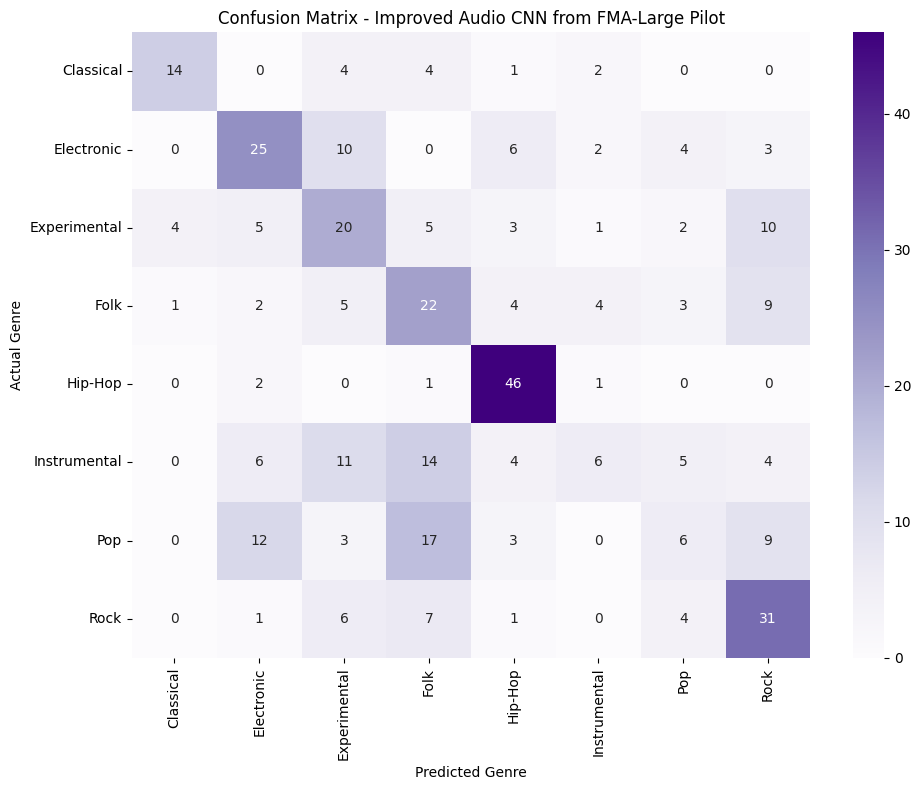

In [10]:
# ============================================================
# 8. CONFUSION MATRIX - IMPROVED CNN
# ============================================================

cm_improved = confusion_matrix(y_test, y_pred_improved)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_improved,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Genre")
plt.ylabel("Actual Genre")
plt.title("Confusion Matrix - Improved Audio CNN from FMA-Large Pilot")
plt.tight_layout()
plt.show()

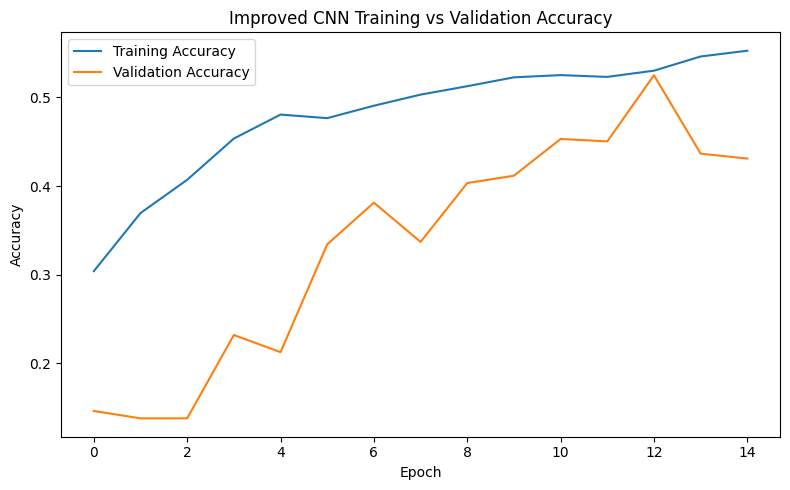

In [11]:
# ============================================================
# 9. TRAINING HISTORY - IMPROVED CNN
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(history_improved.history["accuracy"], label="Training Accuracy")
plt.plot(history_improved.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Improved CNN Training vs Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# 10. BASELINE VS IMPROVED CNN COMPARISON
# ============================================================

cnn_comparison = pd.DataFrame({
    "Model": [
        "Baseline Audio CNN",
        "Improved Audio CNN"
    ],
    "Test Accuracy": [
        baseline_audio_test_accuracy,
        improved_test_accuracy
    ]
})

print("Audio CNN Comparison:")
display(cnn_comparison)

Audio CNN Comparison:


,Model,Test Accuracy
0,Baseline Audio CNN,0.133333
1,Improved Audio CNN,0.453333


In [13]:
# ============================================================
# 11. INTERPRETATION NOTES
# ============================================================

print("1. The baseline CNN established a working end-to-end audio modelling pipeline from FMA-Large.")
print("2. The improved CNN reduces overfitting by using BatchNormalization, GlobalAveragePooling2D, and stronger dropout.")
print("3. Class weights were added to improve sensitivity to genre imbalance within the pilot audio subset.")
print("4. The improved model should be compared directly with the baseline CNN to determine whether architectural refinement improves generalization.")
print("5. Even if the CNN remains below the best structured models, it still demonstrates feasibility of unstructured audio modelling from the approved FMA-Large archive.")

1. The baseline CNN established a working end-to-end audio modelling pipeline from FMA-Large.
2. The improved CNN reduces overfitting by using BatchNormalization, GlobalAveragePooling2D, and stronger dropout.
3. Class weights were added to improve sensitivity to genre imbalance within the pilot audio subset.
4. The improved model should be compared directly with the baseline CNN to determine whether architectural refinement improves generalization.
5. Even if the CNN remains below the best structured models, it still demonstrates feasibility of unstructured audio modelling from the approved FMA-Large archive.


In [14]:
# ============================================================
# SAVE CNN OUTPUTS FOR HYBRID FUSION
# ============================================================

import os
os.makedirs("../data/processed", exist_ok=True)

# Validation probabilities
val_probs_cnn = improved_cnn.predict(X_val)

# Test probabilities
test_probs_cnn = improved_cnn.predict(X_test)

# Save probabilities
np.save("../data/processed/val_probs_cnn.npy", val_probs_cnn)
np.save("../data/processed/test_probs_cnn.npy", test_probs_cnn)

# Save labels and class names
np.save("../data/processed/y_val_cnn.npy", y_val)
np.save("../data/processed/y_test_cnn.npy", y_test)
np.save("../data/processed/cnn_label_classes.npy", label_encoder.classes_)

# Save accuracy
with open("../data/processed/improved_cnn_test_accuracy.txt", "w") as f:
    f.write(str(improved_test_accuracy))

print("Saved CNN outputs for hybrid fusion.")

12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 365ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 374ms/step
Saved CNN outputs for hybrid fusion.


In [15]:
# ============================================================
# SAVE TRAINED IMPROVED CNN MODEL
# ============================================================

import os
os.makedirs("../models", exist_ok=True)

improved_cnn.save("../models/improved_audio_cnn.keras")

print("Saved improved CNN model to ../models/improved_audio_cnn.keras")

Saved improved CNN model to ../models/improved_audio_cnn.keras
